<a href="https://colab.research.google.com/github/Nubiga-lima/kyc-risk-model/blob/main/notebooks/04_model_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## KYC Risk Model — Model Validation

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load Engineered Dataset

In [4]:
df = pd.read_csv("data/processed/kyc_features.csv")
print("Dataset loaded. Shape:", df.shape)
df.head()

Dataset loaded. Shape: (5000, 18)


,customer_id,age,monthly_txn_count,monthly_txn_volume,unusual_txn_flag,product_risk_score,pep_flag,adverse_media_flag,high_risk_jurisdiction,risk_score,risk_class,country_risk_Low,country_risk_Medium,txn_intensity,high_volume_flag,pep_high_risk_interaction,media_pep_combo,behavioural_risk_score
0,1,0.931467,0.644872,1.792729,0,1,0,0,0,0.027894,Low,1.0,0.0,1.169628,0,0,0,0.0
1,2,-0.984769,1.091243,0.800086,0,1,0,0,0,0.043825,Low,1.0,0.0,0.271993,0,0,0,0.0
2,3,1.397579,-1.140612,-0.657155,0,1,0,0,0,0.052781,Low,1.0,0.0,-0.427014,0,0,0,0.0
3,4,-0.674028,-1.363798,1.374910,0,1,0,0,0,0.224441,Medium,1.0,0.0,2.140519,0,0,0,0.0
4,5,-0.518658,-0.024684,0.030972,0,2,0,0,0,0.000000,Low,0.0,1.0,-0.030005,0,0,0,0.0


### 2. Define Features and Target (matching model development notebook)

In [5]:
feature_cols = [
    "age",
    "monthly_txn_count",
    "monthly_txn_volume",
    "product_risk_score",
    "unusual_txn_flag",
    "pep_flag",
    "adverse_media_flag",
    "high_risk_jurisdiction",
    "country_risk_Low",
    "country_risk_Medium",
    "txn_intensity",
    "high_volume_flag",
    "pep_high_risk_interaction",
    "media_pep_combo",
    "behavioural_risk_score"
]

X = df[feature_cols]
y = df["risk_class"]

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature matrix shape: (5000, 15)
Target distribution:
 risk_class
Low       4178
Medium     792
High        30
Name: count, dtype: int64


### 3. Train/Test Split (matching model development notebook)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3500, 15)
Test shape: (1500, 15)


### 4. Refit Baseline & Challenger Models

In [7]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=6, n_estimators=200,
                       random_state=42)

### 5. Cross-Validation (Stability Test)

Using macro-averaged F1 rather than accuracy, since accuracy is misleading
on this imbalanced dataset (a model predicting "Low" for everything would
still score ~85%+ accuracy without being useful).

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(log_reg, X, y, cv=cv, scoring="f1_macro")
rf_cv_scores = cross_val_score(rf, X, y, cv=cv, scoring="f1_macro")

print("=== Cross-Validation Macro F1 ===")
print("Logistic Regression folds:", lr_cv_scores)
print("Random Forest folds:", rf_cv_scores)
print("\nMean Macro F1:")
print("LR:", lr_cv_scores.mean(), "  Std:", lr_cv_scores.std())
print("RF:", rf_cv_scores.mean(), "  Std:", rf_cv_scores.std())

=== Cross-Validation Macro F1 ===
Logistic Regression folds: [0.48259045 0.48230917 0.51333161 0.486225   0.49091048]
Random Forest folds: [0.5095368  0.52018392 0.53611523 0.48341396 0.59050917]

Mean Macro F1:
LR: 0.49107334277311876   Std: 0.011556239843933537
RF: 0.5279518136598321   Std: 0.035673905185055775


### 6. Threshold Sensitivity — High Risk Class

Rather than collapsing predictions to a binary High/Low choice, this
examines how the Random Forest's precision and recall for the "High"
class trade off as the classification threshold changes. This reflects
a realistic KYC decision: a lower threshold flags more customers for
manual review (higher recall, lower precision), and vice versa.

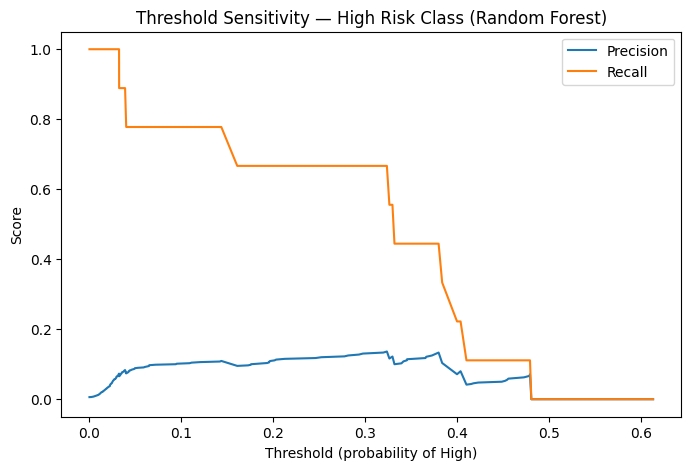

In [9]:
class_labels = list(rf.classes_)
high_index = class_labels.index("High")

probs = rf.predict_proba(X_test)
high_probs = probs[:, high_index]
y_test_binary = (y_test == "High").astype(int)

precision, recall, thresholds = precision_recall_curve(y_test_binary, high_probs)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold (probability of High)")
plt.ylabel("Score")
plt.title("Threshold Sensitivity — High Risk Class (Random Forest)")
plt.legend()
plt.show()

### 7. Confusion Matrix Stability (Train vs Test)

Comparing predictions on the training set vs. the held-out test set
using the same fitted model. Large discrepancies would indicate
overfitting.

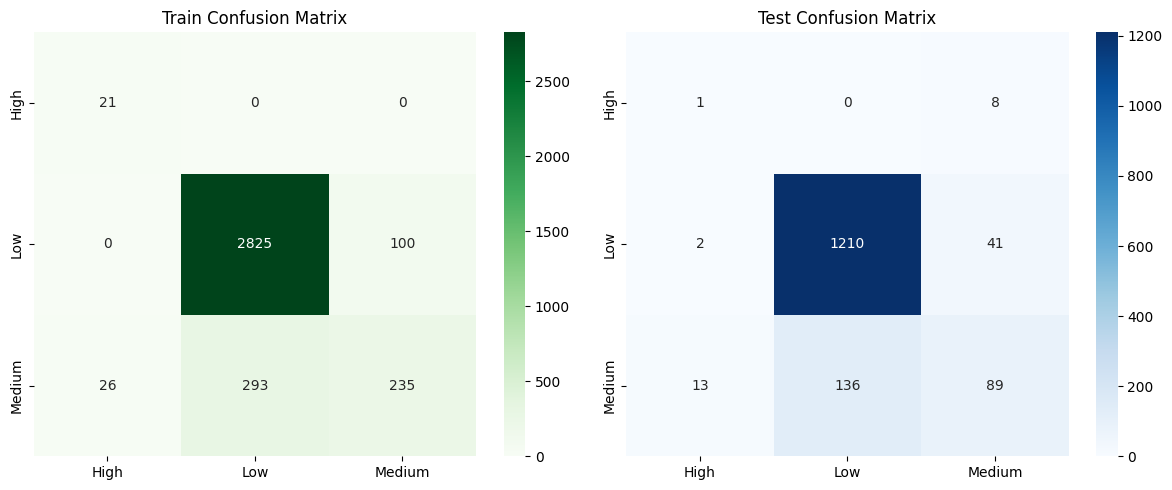

In [10]:
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

cm_train = confusion_matrix(y_train, y_train_pred_rf, labels=rf.classes_)
cm_test = confusion_matrix(y_test, y_test_pred_rf, labels=rf.classes_)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Greens",
            xticklabels=rf.classes_, yticklabels=rf.classes_, ax=ax[0])
ax[0].set_title("Train Confusion Matrix")
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf.classes_, yticklabels=rf.classes_, ax=ax[1])
ax[1].set_title("Test Confusion Matrix")
plt.tight_layout()
plt.show()

### 8. Feature Importance Stability (Across CV Folds)

Rather than fitting a separate model on the held-out test set (which
would misuse the test set for training), stability is assessed by
comparing feature importances across cross-validation folds on the
training data. Consistent importances across folds indicate a stable,
non-overfit reliance on those features.

In [11]:
fold_importances = []

for train_idx, val_idx in cv.split(X, y):
    rf_fold = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        class_weight="balanced",
        random_state=42
    )
    rf_fold.fit(X.iloc[train_idx], y.iloc[train_idx])
    fold_importances.append(rf_fold.feature_importances_)

importance_df = pd.DataFrame(fold_importances, columns=feature_cols)
importance_summary = pd.DataFrame({
    "mean_importance": importance_df.mean(),
    "std_importance": importance_df.std()
}).sort_values("mean_importance", ascending=False)

importance_summary.head(10)

,mean_importance,std_importance
high_risk_jurisdiction,0.271352,0.013240
country_risk_Low,0.139392,0.014349
media_pep_combo,0.090777,0.005420
monthly_txn_volume,0.084144,0.005991
txn_intensity,0.080139,0.007490
pep_flag,0.072769,0.012296
age,0.071736,0.005783
monthly_txn_count,0.065791,0.007692
country_risk_Medium,0.044617,0.002887
pep_high_risk_interaction,0.032364,0.010666


### 9. Challenger vs Baseline Comparison Summary

In [12]:
y_pred_lr = log_reg.predict(X_test)
y_pred_rf = rf.predict(X_test)

print("=== Logistic Regression Report ===")
print(classification_report(y_test, y_pred_lr))
print("=== Random Forest Report ===")
print(classification_report(y_test, y_pred_rf))

print("\nValidation complete. Use these outputs in:")
print("- model_validation_report.md")
print("- model_risk_assessment.md")
print("- monitoring_plan.md")

=== Logistic Regression Report ===
              precision    recall  f1-score   support

        High       0.11      0.78      0.19         9
         Low       0.90      0.97      0.93      1253
      Medium       0.62      0.24      0.34       238

    accuracy                           0.85      1500
   macro avg       0.54      0.66      0.49      1500
weighted avg       0.85      0.85      0.83      1500

=== Random Forest Report ===
              precision    recall  f1-score   support

        High       0.06      0.11      0.08         9
         Low       0.90      0.97      0.93      1253
      Medium       0.64      0.37      0.47       238

    accuracy                           0.87      1500
   macro avg       0.54      0.48      0.49      1500
weighted avg       0.85      0.87      0.85      1500


Validation complete. Use these outputs in:
- model_validation_report.md
- model_risk_assessment.md
- monitoring_plan.md
